In [ ]:
# Titanic Dataset: Exploratory Data Analysis (EDA) Project

In [ ]:
# What We Can Do in This Project:
# 1. Understand the dataset structure - Examine variables, data types, and basic statistics
# 2. Data Cleaning - Handle missing values, correct data formats, and address inconsistencies
# 3. Univariate Analysis - Analyze individual variables to understand their distributions
# 4. Bivariate Analysis - Explore relationships between variables, particularly with the target variable (Survived)
# 5. Multivariate Analysis - Examine complex relationships between multiple variables
# 6. Feature Engineering - Create new variables that might be more predictive
# 7. Visualization - Create charts and graphs to illustrate findings
# 8. Draw Conclusions - Summarize key insights about factors affecting survival

In [1]:
# 1. Import essential libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # scipy.stats is a module within the SciPy library that contains a vast collection of statistical functions, 
                        # probability distributions, and statistical tests. It's essentially a comprehensive statistical toolbox for Python.

# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

print("Libraries imported successfully!")

# pandas is for data manipulation and analysis
# numpy is for numerical operations
# matplotlib and seaborn are for data visualization
# %matplotlib inline ensures plots display directly in Jupyter notebook

Libraries imported successfully!


In [3]:
# 2. Load the dataset
df = pd.read_csv('tested.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
df.head()

# pd.read_csv() loads the CSV file into a pandas DataFrame
# df.shape shows the number of rows and columns
# df.head() displays the first 5 rows to get a quick look at the data

Dataset Shape: (418, 12)

First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# 3. Understand the Dataset Structure

# Get information about data types and missing values
print("Dataset Information:")
df.info()

# Get statistical summary of numerical columns
print("\nStatistical Summary:")
df.describe()

# Check for missing values
print("\nMissing Values:")
missing_data = df.isnull().sum()
missing_data[missing_data > 0]


# df.info() shows column names, data types, and non-null counts
# df.describe() provides statistical measures (mean, std, min, max, etc.) for numerical columns
# df.isnull().sum() counts missing values in each column

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB

Statistical Summary:

Missing Values:


Age       86
Fare       1
Cabin    327
dtype: int64

In [6]:
# 4. Data Cleaning

# Handle missing values in Age column
print("Missing values in Age:", df['Age'].isnull().sum())
df['Age'].fillna(df['Age'].median(), inplace=True)

# Handle missing values in Fare column
print("Missing values in Fare:", df['Fare'].isnull().sum())
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Cabin has too many missing values, we might drop it or create a new feature
print("Missing values in Cabin:", df['Cabin'].isnull().sum())
df['HasCabin'] = df['Cabin'].notnull().astype(int)

# Drop Cabin column as it has too many missing values
df.drop('Cabin', axis=1, inplace=True)

# Verify missing values after cleaning
print("\nMissing values after cleaning:")
df.isnull().sum()


# We fill missing Age values with the median age
# We fill missing Fare values with the median fare
# For Cabin, we create a new binary feature 'HasCabin' indicating whether a passenger had a cabin
# We drop the original Cabin column due to excessive missing values

Missing values in Age: 86
Missing values in Fare: 1
Missing values in Cabin: 327

Missing values after cleaning:


C:\Users\ABHISHEK CHAUDHARY\AppData\Local\Temp\ipykernel_3008\1363841250.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\ABHISHEK CHAUDHARY\AppData\Local\Temp\ipykernel_3008\1363841250.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

Survival Count:
Survived
0    266
1    152
Name: count, dtype: int64

Survival Rate (%):
Survived
0    63.636364
1    36.363636
Name: proportion, dtype: float64


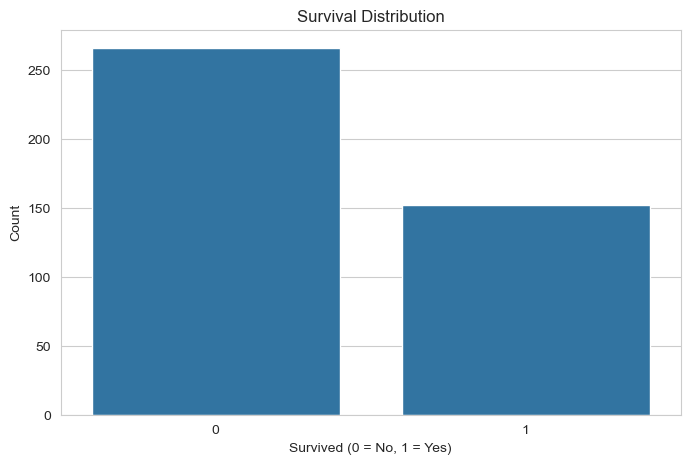

In [10]:
# 5. Univariate Analysis

# Survival rate
survival_count = df['Survived'].value_counts()
survival_rate = df['Survived'].value_counts(normalize=True) * 100

print("Survival Count:")
print(survival_count)
print("\nSurvival Rate (%):")
print(survival_rate)

# Plot survival distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()



# We analyze the target variable 'Survived' to understand the distribution
# value_counts() counts occurrences of each category
# value_counts(normalize=True) gives proportions instead of counts
# We visualize the distribution with a count plot

Passenger Class Distribution:
Pclass
1    107
2     93
3    218
Name: count, dtype: int64

Survival Rate by Passenger Class (%):
Pclass
1    46.728972
2    32.258065
3    33.027523
Name: Survived, dtype: float64


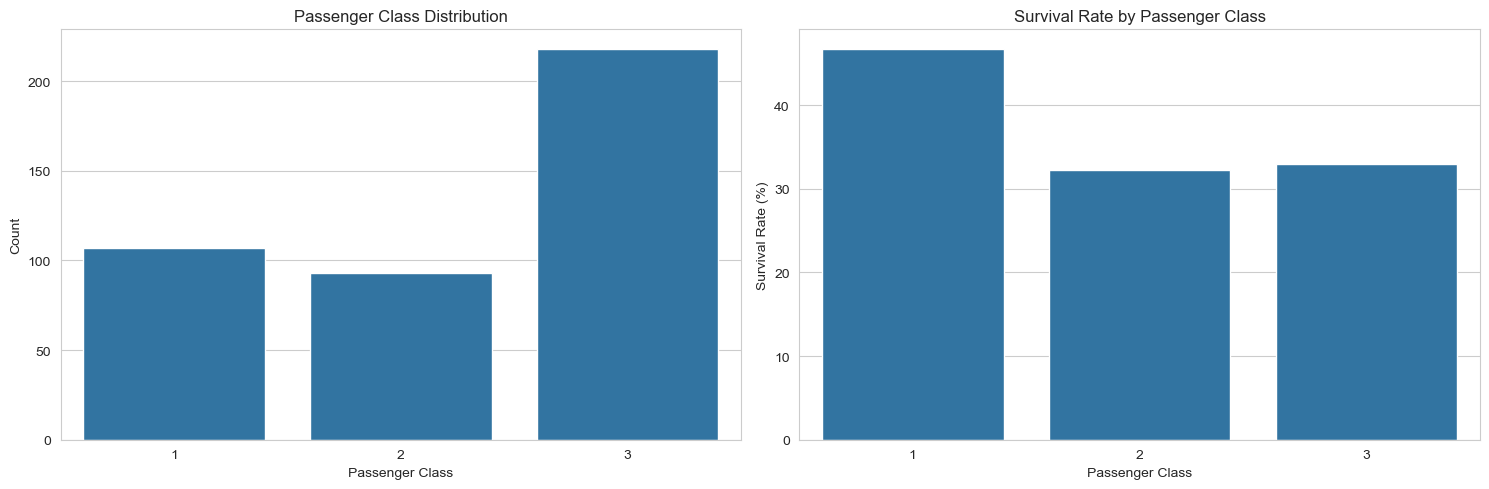

In [11]:
# 6. Analyze Passenger Class (Pclass)

# Passenger class distribution
pclass_dist = df['Pclass'].value_counts().sort_index()
print("Passenger Class Distribution:")
print(pclass_dist)

# Survival rate by passenger class
pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
print("\nSurvival Rate by Passenger Class (%):")
print(pclass_survival)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Passenger class distribution
sns.countplot(x='Pclass', data=df, ax=ax1)
ax1.set_title('Passenger Class Distribution')
ax1.set_xlabel('Passenger Class')
ax1.set_ylabel('Count')

# Survival rate by class
sns.barplot(x=pclass_survival.index, y=pclass_survival.values, ax=ax2)
ax2.set_title('Survival Rate by Passenger Class')
ax2.set_xlabel('Passenger Class')
ax2.set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()



# We examine how passenger class relates to survival
# groupby() groups data by passenger class and calculates mean survival for each group
# We create side-by-side plots to show both distribution and survival rates

Gender Distribution:
Sex
male      266
female    152
Name: count, dtype: int64

Survival Rate by Gender (%):
Sex
female    100.0
male        0.0
Name: Survived, dtype: float64


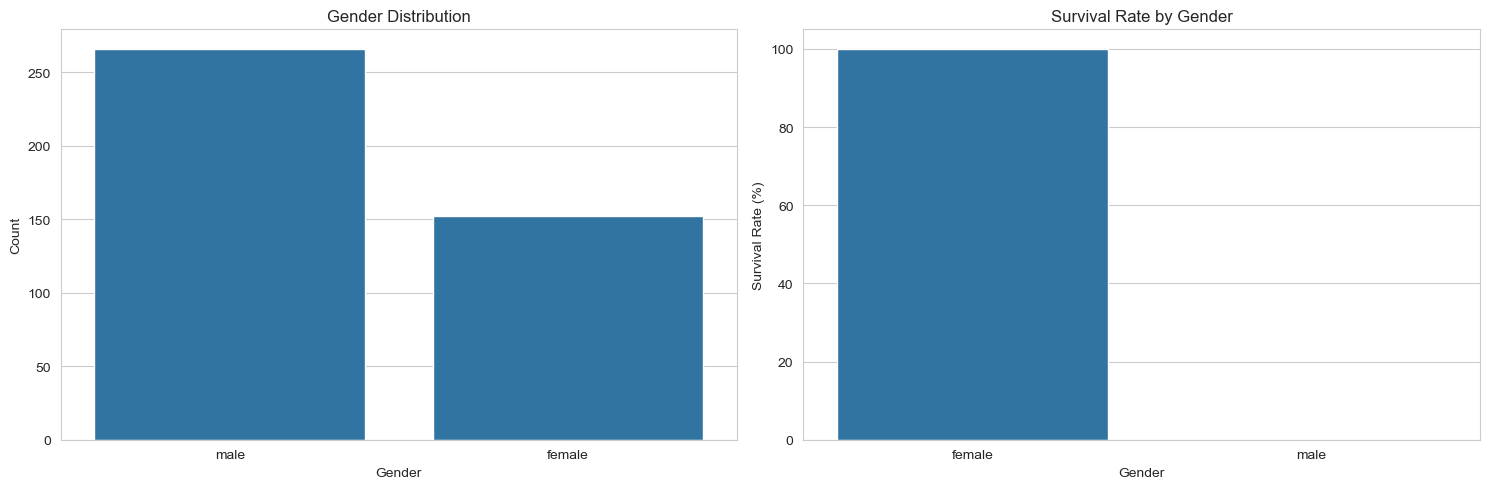

In [12]:
# 7. Analyze Gender (Sex)

# Gender distribution
gender_dist = df['Sex'].value_counts()
print("Gender Distribution:")
print(gender_dist)

# Survival rate by gender
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print("\nSurvival Rate by Gender (%):")
print(gender_survival)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gender distribution
sns.countplot(x='Sex', data=df, ax=ax1)
ax1.set_title('Gender Distribution')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Count')

# Survival rate by gender
sns.barplot(x=gender_survival.index, y=gender_survival.values, ax=ax2)
ax2.set_title('Survival Rate by Gender')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()


# We analyze how gender affects survival (a well-known factor from the Titanic story)
# Similar to passenger class analysis, we examine distribution and survival rates

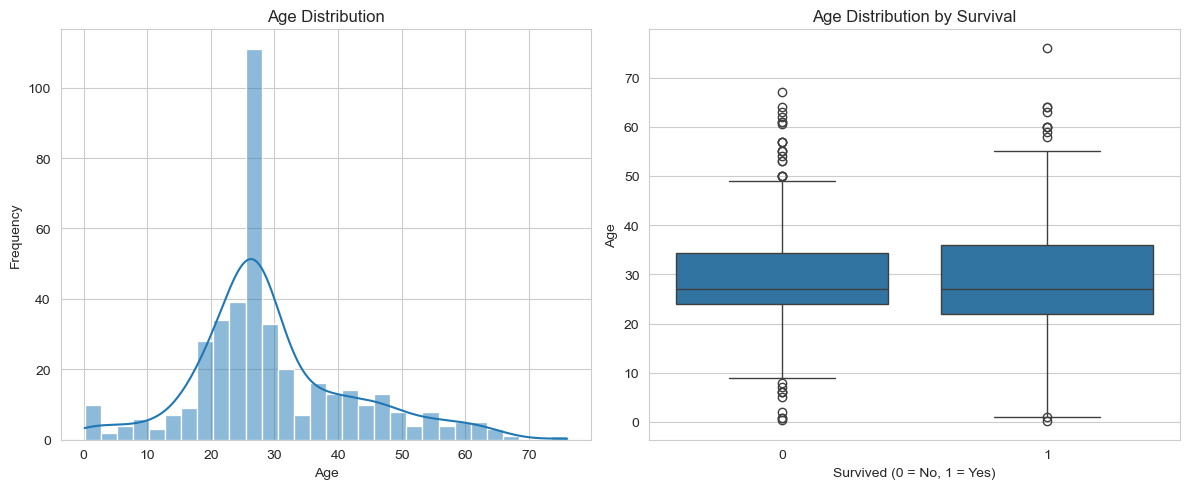

Age Statistics by Survival:
          count       mean        std   min   25%   50%     75%   max
Survived                                                             
0         266.0  29.522218  11.828418  0.33  24.0  27.0  34.375  67.0
1         152.0  29.734145  14.146111  0.17  22.0  27.0  36.000  76.0


In [13]:
# 8. Analyze Age

# Age distribution
plt.figure(figsize=(12, 5))

# Histogram of age distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Box plot of age by survival
plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

# Age statistics by survival
age_stats = df.groupby('Survived')['Age'].describe()
print("Age Statistics by Survival:")
print(age_stats)


# We visualize the distribution of ages using a histogram with kernel density estimation
# A box plot shows the age distribution for survivors vs. non-survivors
# We calculate descriptive statistics for age grouped by survival status

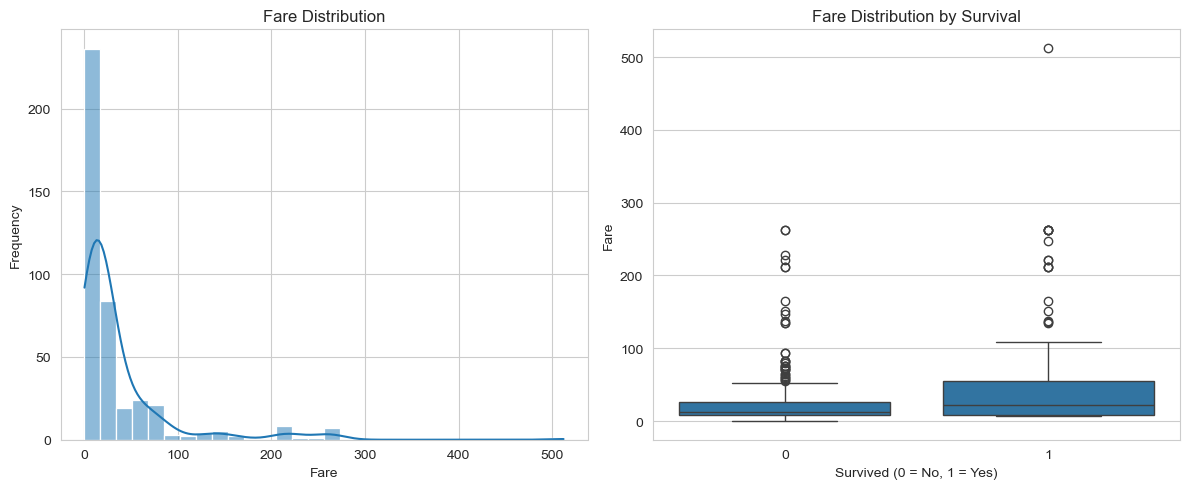

Fare Statistics by Survival:
          count       mean        std   min      25%      50%      75%  \
Survived                                                                 
0         266.0  27.478728  41.009676  0.00  7.85420  13.0000  26.4125   
1         152.0  49.747699  73.108716  6.95  8.62605  21.5125  55.4417   

               max  
Survived            
0         262.3750  
1         512.3292  


In [14]:
# 9. Analyze Fare

# Fare distribution
plt.figure(figsize=(12, 5))

# Histogram of fare distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')

# Box plot of fare by survival
plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()

# Fare statistics by survival
fare_stats = df.groupby('Survived')['Fare'].describe()
print("Fare Statistics by Survival:")
print(fare_stats)


# Similar to age analysis, we examine fare distribution and its relationship with survival
# The fare is often correlated with passenger class and can indicate socioeconomic status

Survival by Passenger Class and Gender:
Survived         0    1  All
Pclass Sex                  
1      female    0   50   50
       male     57    0   57
2      female    0   30   30
       male     63    0   63
3      female    0   72   72
       male    146    0  146
All            266  152  418

Survival Rates by Passenger Class and Gender (%):
Survived           0      1
Pclass Sex                 
1      female    0.0  100.0
       male    100.0    0.0
2      female    0.0  100.0
       male    100.0    0.0
3      female    0.0  100.0
       male    100.0    0.0


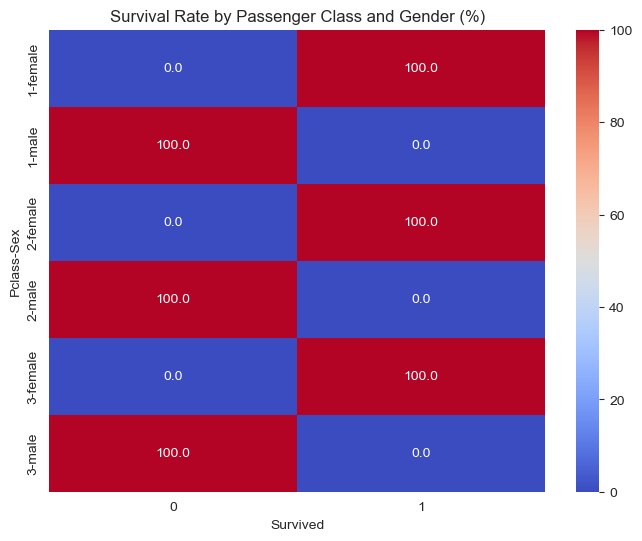

In [15]:
# 10. Bivariate Analysis - Cross-tabulations

# Create cross-tabulations to understand relationships
print("Survival by Passenger Class and Gender:")
cross_tab = pd.crosstab([df['Pclass'], df['Sex']], df['Survived'], margins=True)
print(cross_tab)

# Calculate survival rates
cross_tab_percent = pd.crosstab([df['Pclass'], df['Sex']], df['Survived'], 
                                normalize='index') * 100
print("\nSurvival Rates by Passenger Class and Gender (%):")
print(cross_tab_percent)

# Visualize with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cross_tab_percent, annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Survival Rate by Passenger Class and Gender (%)')
plt.show()


# Cross-tabulation shows the relationship between multiple categorical variables
# We examine how passenger class and gender together affect survival
# A heatmap provides a visual representation of survival rates across combinations

In [16]:
# 11. Feature Engineering

# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                        labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])

# Create fare groups
df['FareGroup'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

# Extract title from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles
title_counts = df['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create is alone feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("New features created successfully!")
print("\nTitle distribution:")
print(df['Title'].value_counts())


# We create age groups to simplify age analysis
# Fare groups help categorize passengers by fare amount
# Extracting titles from names can reveal social status
# Family size and alone status might be relevant to survival

New features created successfully!

Title distribution:
Title
Mr        240
Miss       78
Mrs        72
Master     21
Rare        7
Name: count, dtype: int64


<>:11: SyntaxWarning: invalid escape sequence '\.'
<>:11: SyntaxWarning: invalid escape sequence '\.'
C:\Users\ABHISHEK CHAUDHARY\AppData\Local\Temp\ipykernel_3008\2610411507.py:11: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


C:\Users\ABHISHEK CHAUDHARY\AppData\Local\Temp\ipykernel_3008\1366506592.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_survival = df.groupby('AgeGroup')['Survived'].mean() * 100


Survival Rate by Age Group (%):
AgeGroup
Child          48.000000
Teen           41.379310
Adult          33.590734
Middle-aged    39.361702
Senior         36.363636
Name: Survived, dtype: float64

Survival Rate by Family Size (%):
FamilySize
1     26.877470
2     48.648649
3     52.631579
4     71.428571
5     28.571429
6     66.666667
7     25.000000
8     50.000000
11    50.000000
Name: Survived, dtype: float64

Survival Rate by Title (%):
Title
Master      0.000000
Miss      100.000000
Mr          0.000000
Mrs       100.000000
Rare       28.571429
Name: Survived, dtype: float64


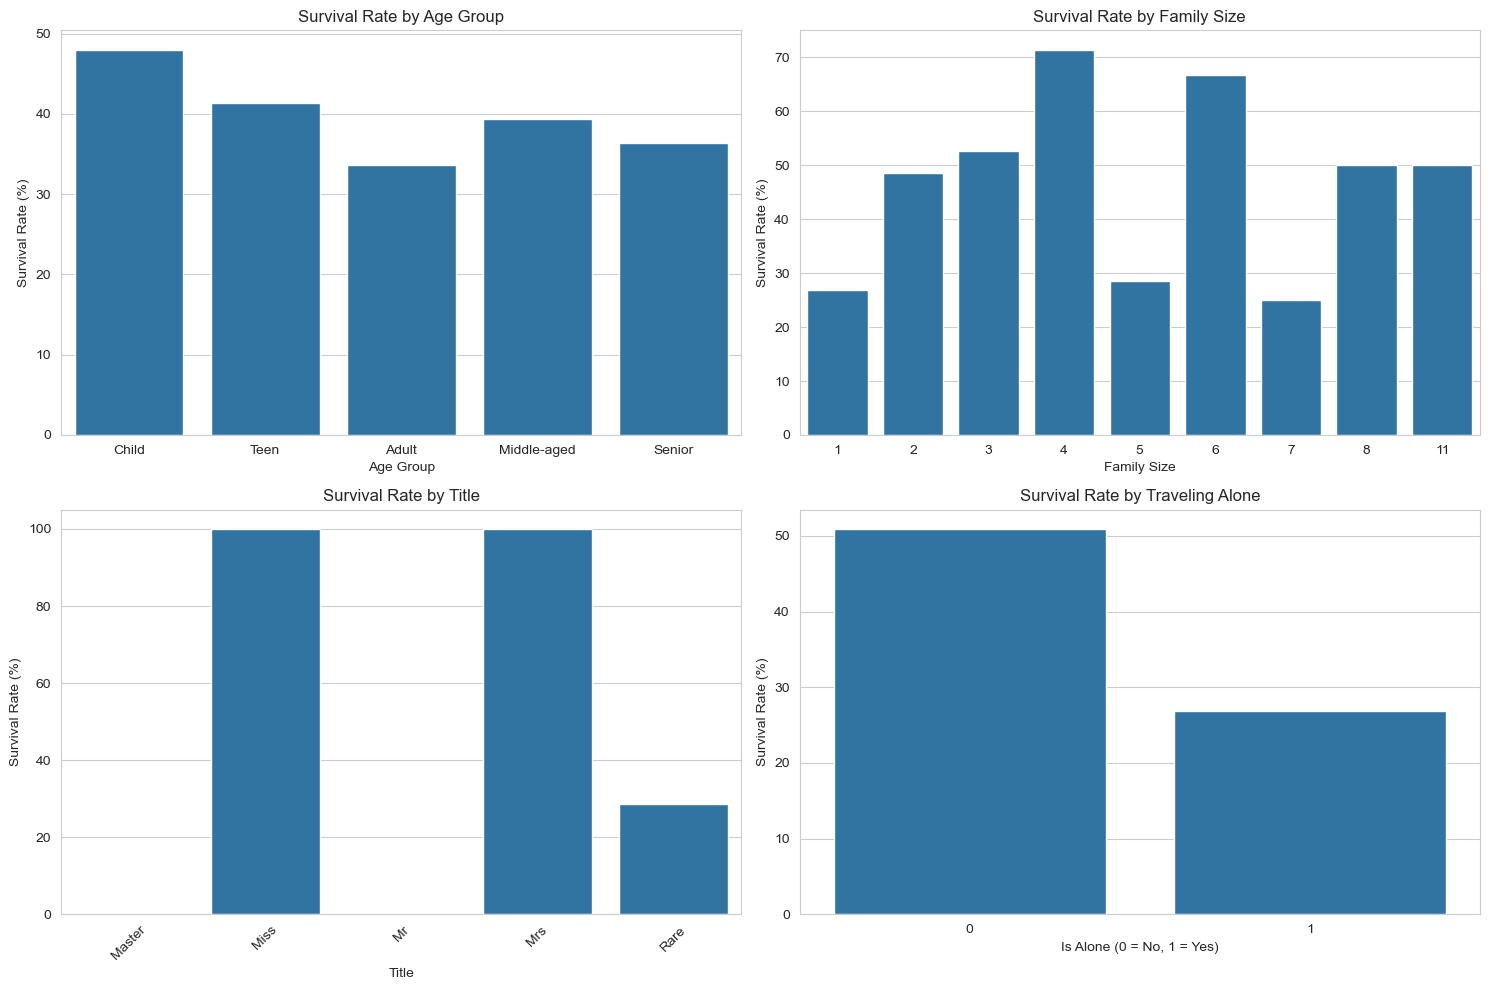

In [17]:
# 12: Analyze New Features

# Analyze survival by age group
age_group_survival = df.groupby('AgeGroup')['Survived'].mean() * 100
print("Survival Rate by Age Group (%):")
print(age_group_survival)

# Analyze survival by family size
family_size_survival = df.groupby('FamilySize')['Survived'].mean() * 100
print("\nSurvival Rate by Family Size (%):")
print(family_size_survival)

# Analyze survival by title
title_survival = df.groupby('Title')['Survived'].mean() * 100
print("\nSurvival Rate by Title (%):")
print(title_survival)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Age group survival
sns.barplot(x=age_group_survival.index, y=age_group_survival.values, ax=axes[0,0])
axes[0,0].set_title('Survival Rate by Age Group')
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Survival Rate (%)')

# Family size survival
sns.barplot(x=family_size_survival.index, y=family_size_survival.values, ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Family Size')
axes[0,1].set_xlabel('Family Size')
axes[0,1].set_ylabel('Survival Rate (%)')

# Title survival
sns.barplot(x=title_survival.index, y=title_survival.values, ax=axes[1,0])
axes[1,0].set_title('Survival Rate by Title')
axes[1,0].set_xlabel('Title')
axes[1,0].set_ylabel('Survival Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Is alone survival
alone_survival = df.groupby('IsAlone')['Survived'].mean() * 100
sns.barplot(x=alone_survival.index, y=alone_survival.values, ax=axes[1,1])
axes[1,1].set_title('Survival Rate by Traveling Alone')
axes[1,1].set_xlabel('Is Alone (0 = No, 1 = Yes)')
axes[1,1].set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()


# We analyze how our newly created features relate to survival
# This helps identify additional patterns that might not be apparent with original features

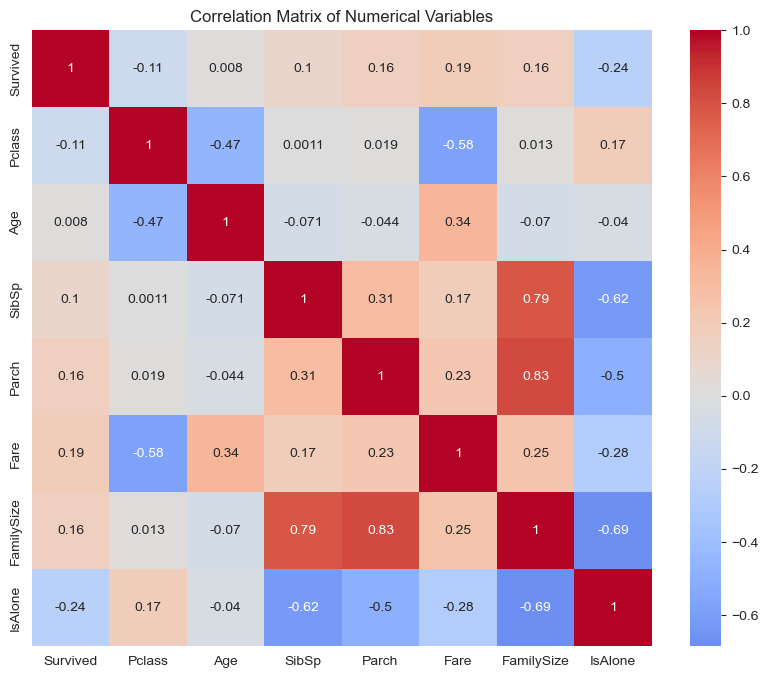

Correlation with Survival:
Survived      1.000000
Fare          0.192036
FamilySize    0.161803
Parch         0.159120
SibSp         0.099943
Age           0.008035
Pclass       -0.108615
IsAlone      -0.244187
Name: Survived, dtype: float64


In [18]:
# 13: Correlation Analysis

# Select numerical columns for correlation analysis
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
correlation_matrix = df[numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# Check correlation of each variable with survival
survival_corr = correlation_matrix['Survived'].sort_values(ascending=False)
print("Correlation with Survival:")
print(survival_corr)


# Correlation matrix shows relationships between numerical variables
# Values close to 1 indicate strong positive correlation
# Values close to -1 indicate strong negative correlation
# Values near 0 indicate weak or no correlation

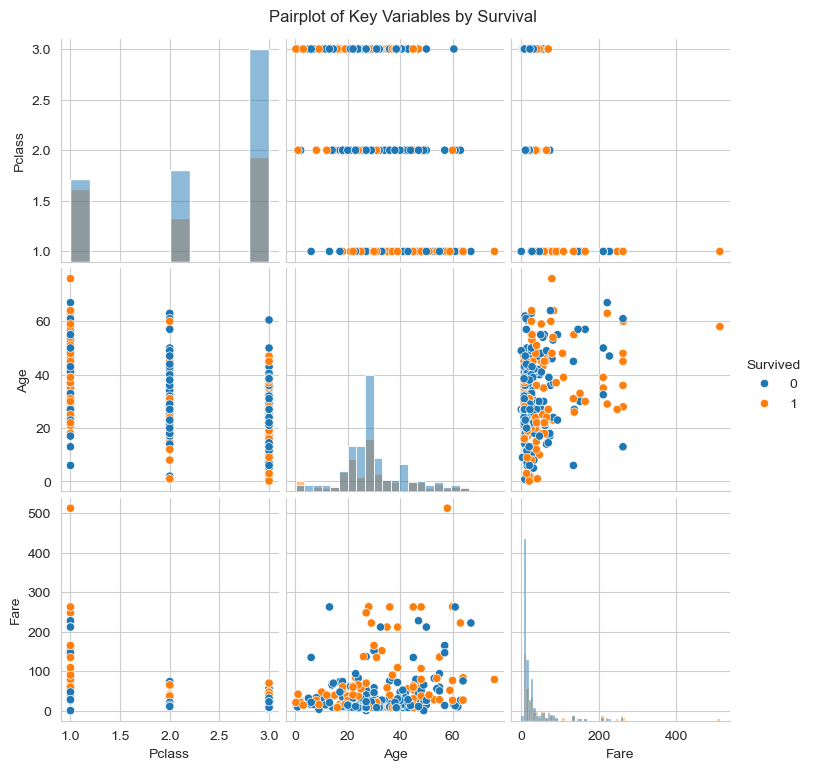

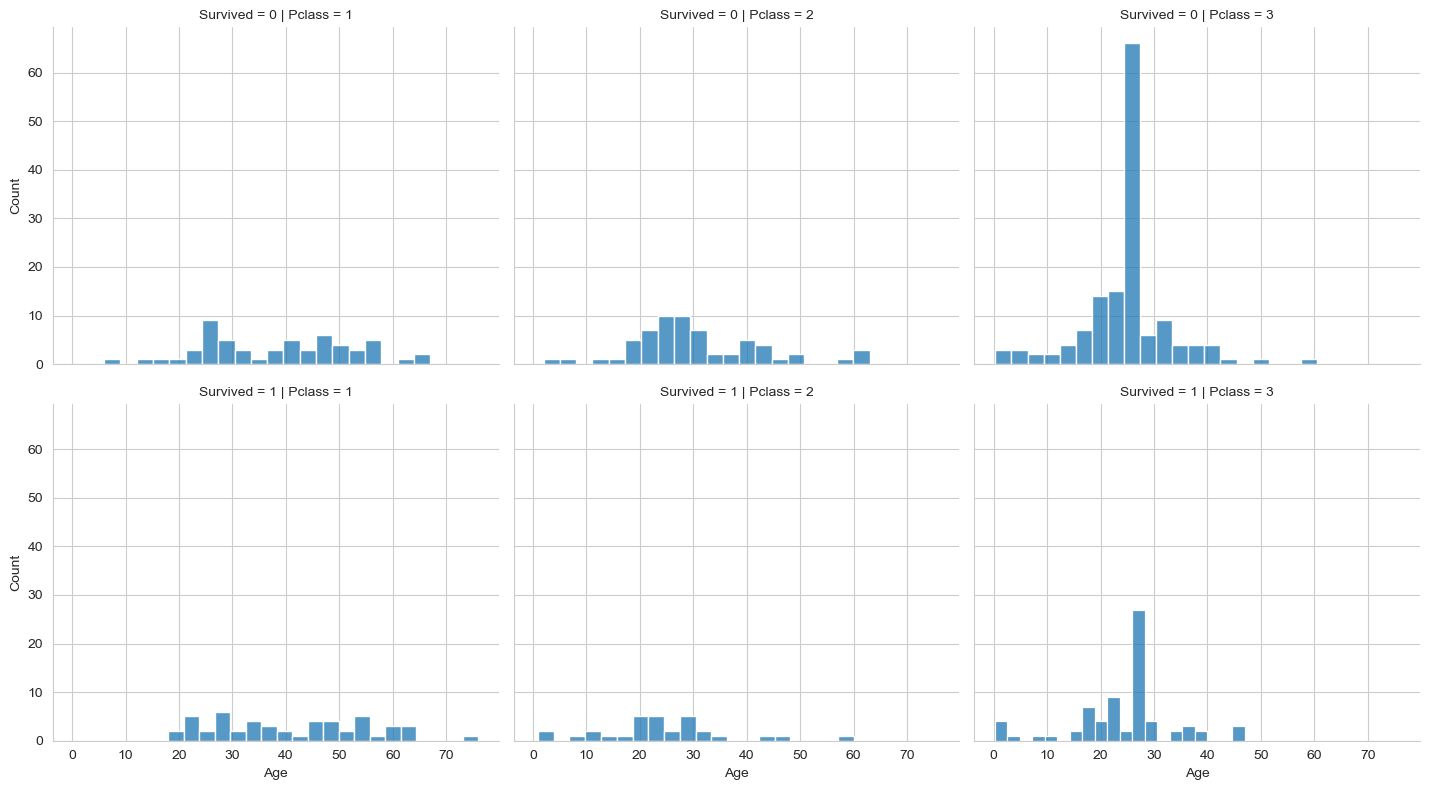

In [20]:
# 14: Multivariate Analysis

# Create a pairplot of key variables
key_vars = ['Survived', 'Pclass', 'Age', 'Fare', 'Sex', 'Embarked']
sns.pairplot(df[key_vars].dropna(), hue='Survived', diag_kind='hist')
plt.suptitle('Pairplot of Key Variables by Survival', y=1.02)
plt.show()

# Create a facet grid of age distribution by class and survival
g = sns.FacetGrid(df, col='Pclass', row='Survived', height=4, aspect=1.2)
g.map(sns.histplot, 'Age', bins=20)
g.add_legend()
plt.show()


# Pairplot shows relationships between multiple variables simultaneously
# Facet grid allows us to see how distributions change across different combinations of variables

=== TITANIC EDA KEY INSIGHTS ===
Total passengers in dataset: 418
Overall survival rate: 36.4%
Female survival rate: 100.0%
Male survival rate: 0.0%
First class survival rate: 46.7%
Third class survival rate: 33.0%

=== KEY FACTORS AFFECTING SURVIVAL ===
1. Gender: Females had significantly higher survival rates
2. Passenger Class: Higher classes had better survival chances
3. Age: Children had priority in lifeboats
4. Fare: Higher fare (indicating wealth) correlated with survival
5. Family Size: Moderate family sizes had better survival rates


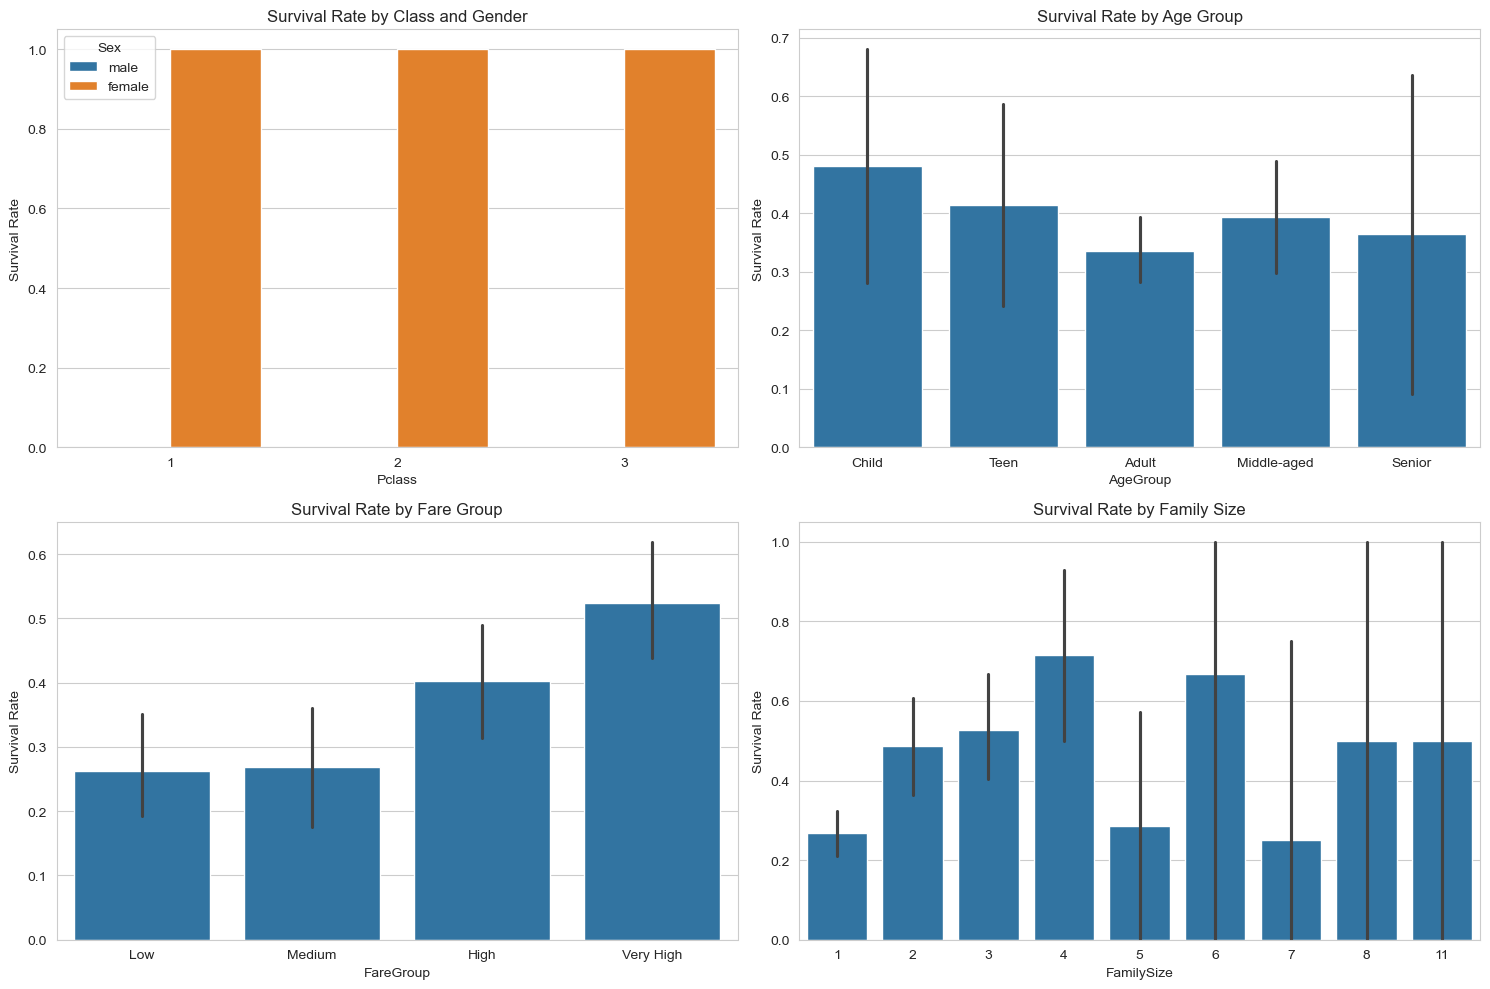

In [21]:
# 15: Summary and Key Insights

# Calculate key statistics
total_passengers = len(df)
survival_rate = df['Survived'].mean() * 100
female_survival = df[df['Sex'] == 'female']['Survived'].mean() * 100
male_survival = df[df['Sex'] == 'male']['Survived'].mean() * 100
first_class_survival = df[df['Pclass'] == 1]['Survived'].mean() * 100
third_class_survival = df[df['Pclass'] == 3]['Survived'].mean() * 100

print("=== TITANIC EDA KEY INSIGHTS ===")
print(f"Total passengers in dataset: {total_passengers}")
print(f"Overall survival rate: {survival_rate:.1f}%")
print(f"Female survival rate: {female_survival:.1f}%")
print(f"Male survival rate: {male_survival:.1f}%")
print(f"First class survival rate: {first_class_survival:.1f}%")
print(f"Third class survival rate: {third_class_survival:.1f}%")

# Identify the most important factors
print("\n=== KEY FACTORS AFFECTING SURVIVAL ===")
print("1. Gender: Females had significantly higher survival rates")
print("2. Passenger Class: Higher classes had better survival chances")
print("3. Age: Children had priority in lifeboats")
print("4. Fare: Higher fare (indicating wealth) correlated with survival")
print("5. Family Size: Moderate family sizes had better survival rates")

# Create a final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Survival by class and gender
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, ax=axes[0,0])
axes[0,0].set_title('Survival Rate by Class and Gender')
axes[0,0].set_ylabel('Survival Rate')

# Survival by age group
sns.barplot(x='AgeGroup', y='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title('Survival Rate by Age Group')
axes[0,1].set_ylabel('Survival Rate')

# Survival by fare group
sns.barplot(x='FareGroup', y='Survived', data=df, ax=axes[1,0])
axes[1,0].set_title('Survival Rate by Fare Group')
axes[1,0].set_ylabel('Survival Rate')

# Survival by family size
sns.barplot(x='FamilySize', y='Survived', data=df, ax=axes[1,1])
axes[1,1].set_title('Survival Rate by Family Size')
axes[1,1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()



# We summarize the key findings from our analysis
# Calculate important statistics that tell the story of the Titanic disaster
# Create a final visualization that highlights the most important factors

In [ ]:
# Conclusion -: 
# This comprehensive EDA of the Titanic dataset has revealed several important patterns:

# Gender was the strongest predictor of survival, with women having much higher survival rates.

# Passenger class mattered significantly, with first-class passengers having the highest survival rates.

# Age played a role, with children having better survival chances.

# Fare (indicating wealth) was positively correlated with survival.

# Family size showed a complex relationship, with moderate family sizes faring best.